In [210]:
# Here are all imports of the document
try:
    import ensembler
except:
    ! pip install ensembler-rinikerlab
    import ensembler
    
    
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import simpson

from ensembler.potentials import OneD  as pot
from ensembler.visualisation import plotPotentials as vis
from ensembler.samplers.optimizers import conjugate_gradient
from ensembler.system.perturbed_system import perturbedSystem



# Definition of Dummy System:
let's define a very simple dummy system building an alchemical double well 
potential from two harmonic oscillators. and a very simple symmetric system.


''

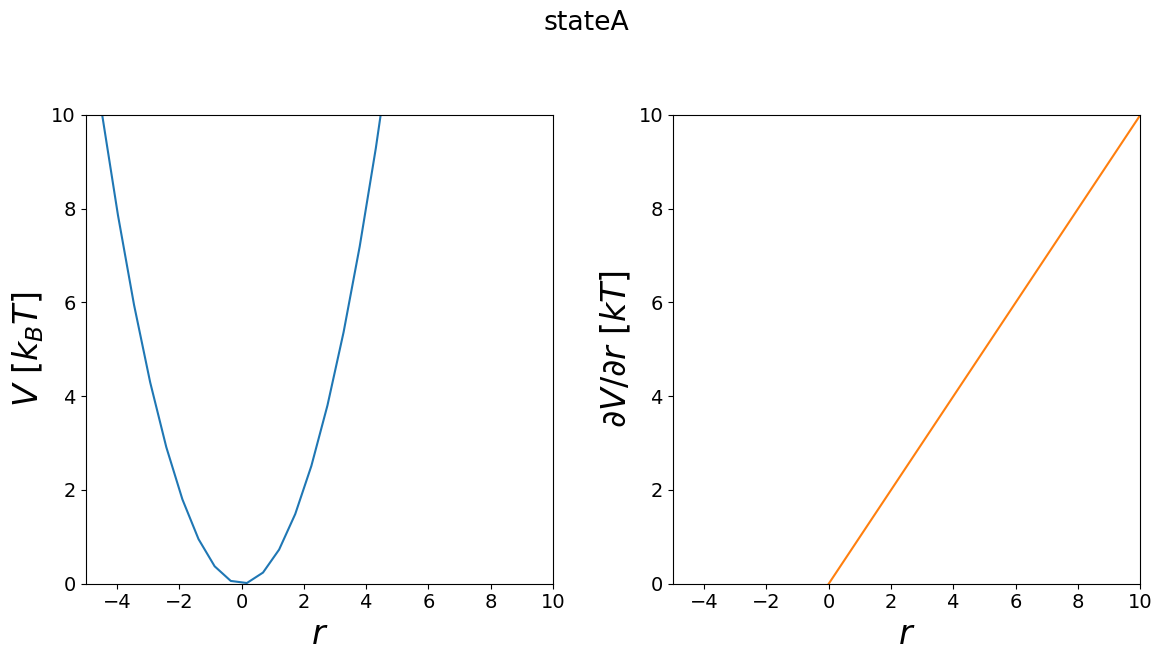

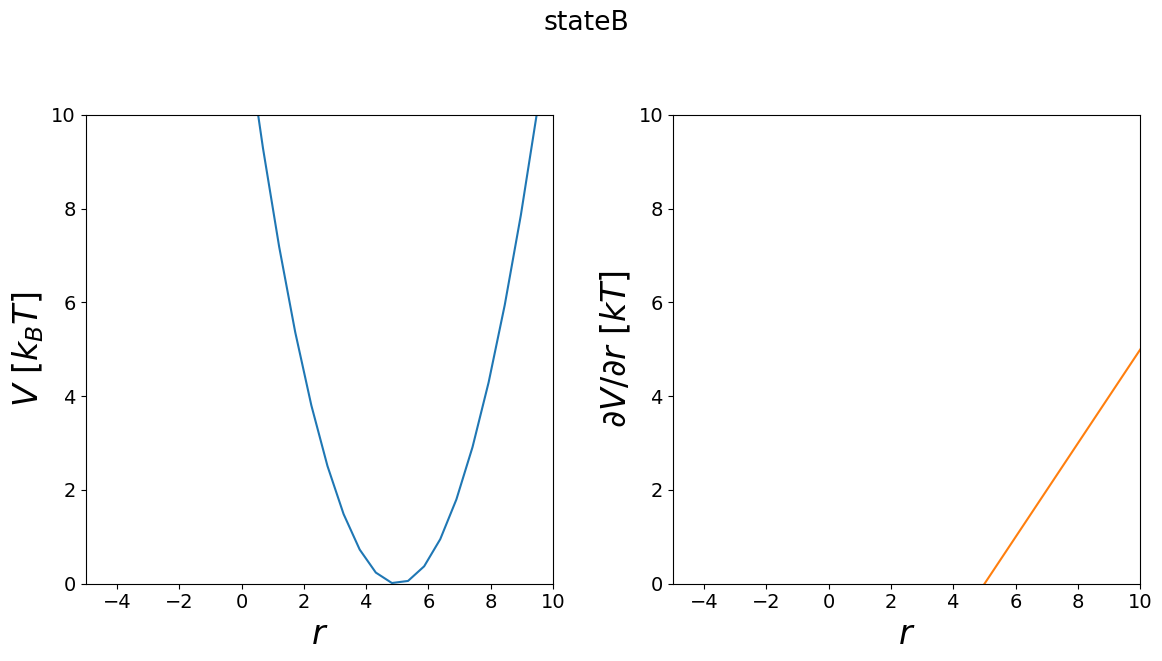

In [211]:
# Note very reduced units ahead!
#coordinate dimension (e.g. bond length)
r=np.linspace(-5,10,30)

# two different states for the dw potential (e.g. 2 diff bond types)
stateA = pot.harmonicOscillatorPotential(k=1, x_shift=0, y_shift=0)
stateB = pot.harmonicOscillatorPotential(k=1, x_shift=5, y_shift=0)

# vis
vis.plot_1DPotential(stateA, r, title="stateA", y_range=[0,10])
vis.plot_1DPotential(stateB, r, title="stateB", y_range=[0,10])
;

In [212]:
# Now let's do some alchemistry!
# linear coupling of potential = Alchemical Potential
alchemicalState = pot.linearCoupledPotentials(Va=stateA, Vb=stateB, 
                                                   lam=0.5)
    
print("Coupling Function: ", alchemicalState.V_functional)
print("Derivation by lambda: ", alchemicalState.dVdlam_functional)


Coupling Function:  V_a*(1 - λ) + V_b*λ
Derivation by lambda:  -V_a + V_b


Text(0.5, 1.0, 'Alchemical Double Well Potential')

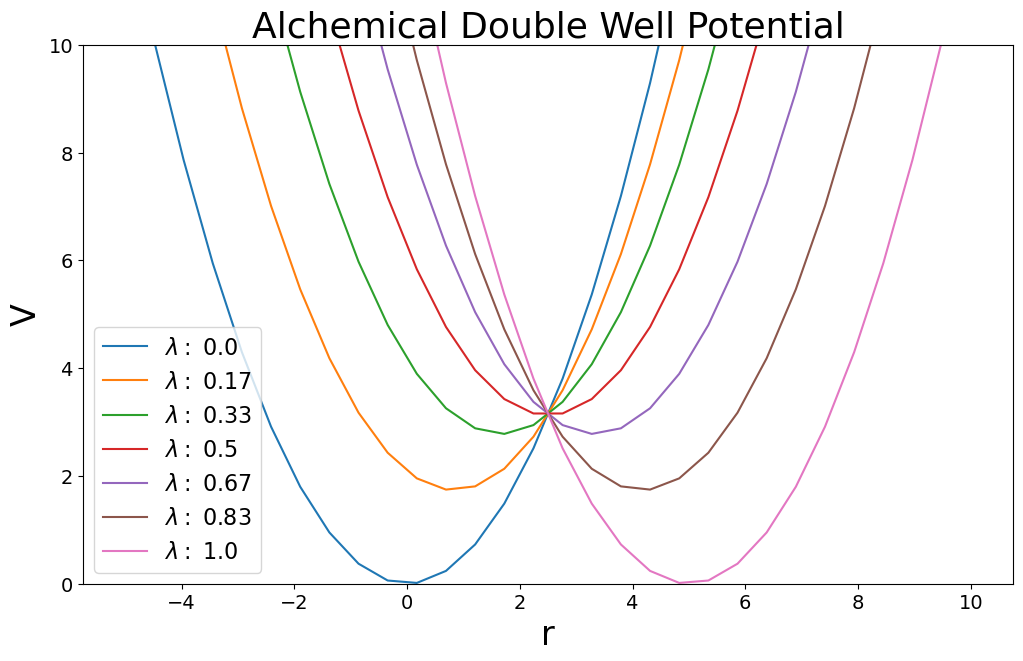

In [213]:
#Calculate dw pot via lambda space.
lambda_space = np.linspace(0,1, 7)
for lam in lambda_space:
    alchemicalState.set_lambda(lam)
    Vs = alchemicalState.ene(r)
    plt.plot(r, Vs, label=f"$\lambda:$ {round(lam,2)}")

plt.legend()
plt.ylim([0,10])
plt.ylabel("V")
plt.xlabel("r")
plt.title("Alchemical Double Well Potential")


In [214]:
#barrier height - assumed result:
alchemicalState.set_lambda(0.5)
V_barrier = alchemicalState.ene(2.5)

print("Barrier Potential Energy: ", V_barrier)

Barrier Potential Energy:  3.125


# Next we wanted to estimate the transformation difficulty:

1. Approach: use local minima to estimate FE difference. 
   <br /> <br />

    $dG^{BA}_{estm} = H(r_B, \lambda_B)-H(r_A, \lambda_A)$
    
   <br /> <br />
    
    problematic: 
    - no Entropy (hm...)
    - a specific local minimum (nearly impossible to solve this efficiently)
    - does not assumes the required 'transformation' work / thermodynamic 
    length. (let's see what we can do here)

In [215]:
stateA_min = min(stateA.ene(r))
stateB_min = min(stateB.ene(r))

from ensembler.analysis.freeEnergyCalculation import zwanzig

estimator = zwanzig()

dG = estimator.calculate(stateA_min, stateB_min)
dG

-0.0

  Correct free energy for this system, bad description for transformation barrier.
  <br /> <br />
  <br /> <br />


2. Use the derivative by lambda to estimate the work required to reach the 
barrier.
  <br /> <br />

    $w_{est} = \sum^N_{\lambda_i}(\partial H(r, \lambda)/\partial \lambda)$

   <br /> <br />

    with: 
      r as coordinate space
   
  afterwards estimate by integration:
     $w_{est}=\sum^N_{i,j}(H(r, \lambda_i)-H(r, \lambda_j))$

  this equals in our case the derivative translates to: (so this covers 
  several of our ideas i call this dvdlam)
  
   $w_{est} = -V_a(r) + V_b(r) $ 
  
  


In [216]:
alchemicalState.dVdlam_functional

-V_a + V_b

Text(0.5, 1.0, 'Linear Coupled States')

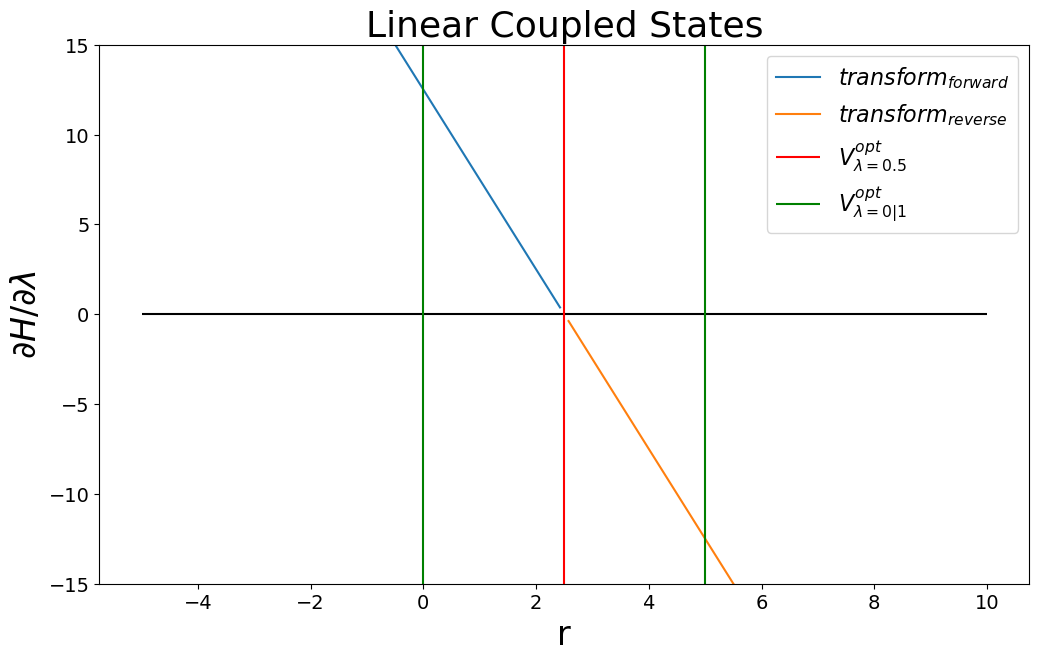

In [217]:
#Visualize Derivative along 
r2=np.linspace(-5,10,100)
dvdlams = alchemicalState.dvdlam(r2)
forwad_indices = np.where(dvdlams>0)
reverse_indices = np.where(dvdlams<0)

plt.hlines(xmin=-5,xmax=10, y=0, color="k")

plt.plot(r2[forwad_indices], dvdlams[forwad_indices],
         label="$transform_{forward}$")
plt.plot(r2[reverse_indices], dvdlams[reverse_indices],
         label="$transform_{reverse}$")

plt.vlines(x=2.5, ymin=-15, ymax=15, color="r", label="$V^{opt}_{\lambda=0.5}$")
plt.vlines(x=[0,5], ymin=-15, ymax=15, color="g", label="$V^{opt}_{\lambda=0 "
                                                        "| 1}$")

plt.legend()
plt.ylim([-15,15])
plt.ylabel("$\partial H / \partial\lambda$")
plt.xlabel("r")
plt.title("Linear Coupled States")


Text(0.5, 1.0, 'Linear Coupled States')

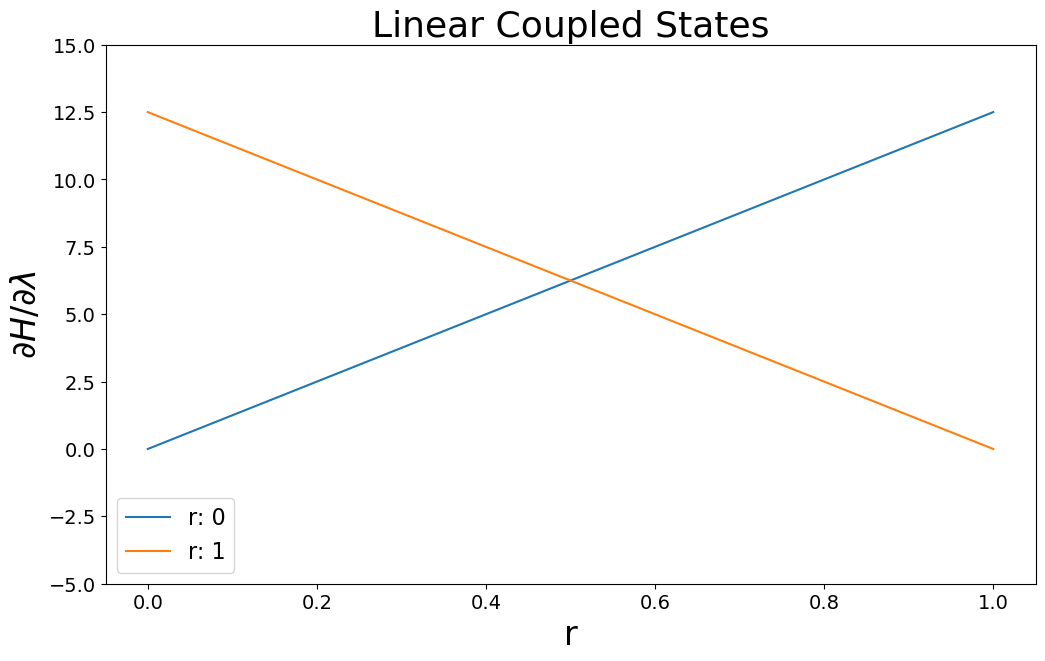

In [221]:
#Visualize Derivative along 
lambda_space = np.linspace(0,1,10)
dvdlams0=[]
dvdlams1=[]

minrStateA=0
minrStateB=5
for lam in lambda_space:
    alchemicalState.set_lambda(lam)
    dvdlam0 = alchemicalState.ene(minrStateA)
    dvdlams0.append(dvdlam0)
    
    dvdlam1 = alchemicalState.ene(minrStateB)
    dvdlams1.append(dvdlam1)

plt.plot(lambda_space, dvdlams0, label="r: 0")
plt.plot(lambda_space, dvdlams1, label="r: 1")

plt.legend()
plt.ylim([-5,15])
plt.ylabel("$\partial H / \partial\lambda$")
plt.xlabel("r")
plt.title("Linear Coupled States")


3. Summation of lambda window difference with optimization:
   <br /> <br />
   <br /> <br />
    
   Procedure:
      - for good rs - optimize on each lambda.
      - determin Potential and dVdlam
      - detect sign chain for finding barrier if possible
      - sum all direction belonging parts up for retrieving the required work.

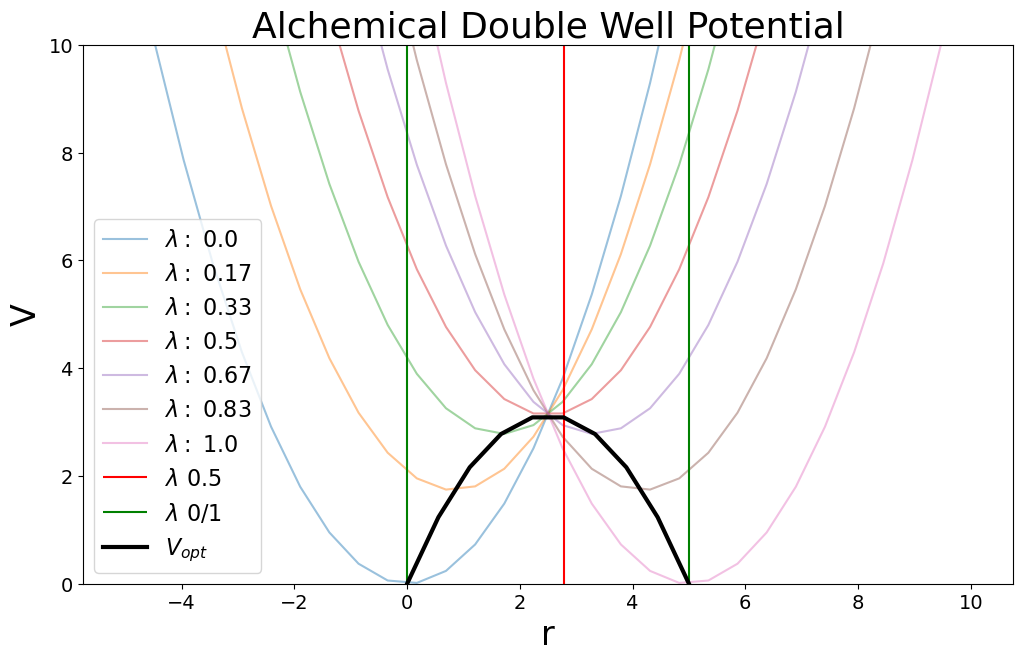

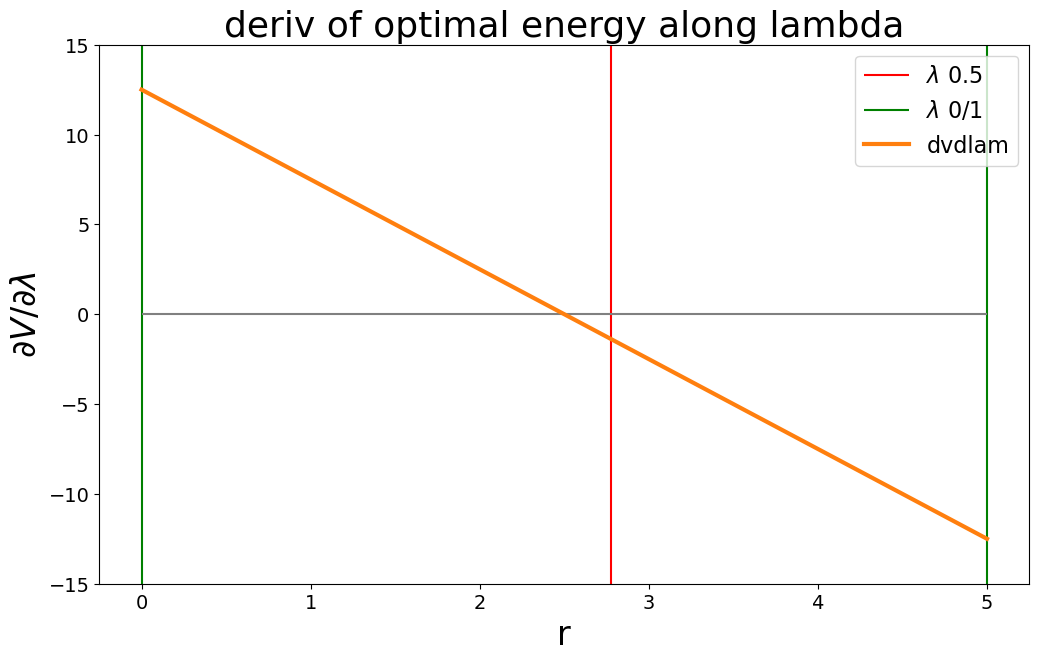

In [176]:
# 1. Step: Calculate an Optimization and get only the minima results

## define some functions for less text:
def calculate_optimization(alchemicalState, lambda_space = np.linspace(0,1, 10)):
    '''
    this is a potential dummy optimization function 
    '''
    
    #Optimization Setup
    optimizer = conjugate_gradient()
    sys = perturbedSystem(potential=alchemicalState, sampler=optimizer,  
                      start_position=0, lam=0)
    minVs=[]
    minRs=[]
    minDvdlams=[]
    for lam in lambda_space:
        sys.set_lambda(lam)
        cur_state = sys.simulate(100, withdraw_traj=True, init_system=False,
                                 verbosity=False)
        minr = cur_state.position
        minV = cur_state.total_potential_energy
        minDvdlam = alchemicalState.dvdlam(minr)
        
        minVs.append(minV)
        minRs.append(minr)
        minDvdlams.append(minDvdlam)
     
    minVs = np.array(minVs)
    minRs = np.array(minRs)
    minDvdlams = np.array(minDvdlams)   

    return minVs, minRs, minDvdlams


def vis_optimization(alchemicalState,minVs, minRs, minDvdlam):
    #Calculate dw pot via lambda space.
    lambda_space = np.linspace(0,1, 7)
    for lam in lambda_space:
        alchemicalState.set_lambda(lam)
        Vs = alchemicalState.ene(r)
        plt.plot(r, Vs, label=f"$\lambda:$ {round(lam,2)}", alpha=0.45)
        
    plt.ylim([0,10])
    plt.ylabel("$V_{min}$")
    plt.xlabel("$\lambda$")
    plt.title("optimal energy along lambda")
    plt.vlines(x=minRs[len(minRs)//2], ymin=-15, ymax=15, color="r",
               label="$\lambda$ 0.5")
    plt.vlines(x=[minRs[0],minRs[-1]], ymin=-15, ymax=15, color="g", 
               label="$\lambda$ 0/1")
    plt.plot(minRs, minVs, c="k", lw=3, label="$V_{opt}$")
    plt.legend()
    
    
    
    plt.legend()
    plt.ylim([0,10])
    plt.ylabel("V")
    plt.xlabel("r")
    plt.title("Alchemical Double Well Potential")
    plt.show()
    
    
    plt.vlines(x=minRs[len(minRs)//2], ymin=-15, ymax=15, color="r", 
               label="$\lambda$ 0.5")
    plt.vlines(x=[minRs[0],minRs[-1]], ymin=-15, ymax=15, color="g", label="$\lambda$ 0/1")
    plt.hlines(xmin=minRs[0],xmax=minRs[-1], y=0, color="grey")
    plt.plot(minRs, minDvdlam, label=f"dvdlam", lw=3,  color="C1")
    
    plt.legend()
    plt.ylim([-15,15])
    plt.ylabel("$\partial V / \partial\lambda$")
    plt.xlabel("r")
    plt.title("deriv of optimal energy along lambda")
    plt.show()

lambda_space = np.linspace(0,1, 10)
minVs, minRs, minDvdlams = calculate_optimization(alchemicalState, 
                                                  lambda_space=lambda_space)

vis_optimization(alchemicalState, minVs, minRs, minDvdlams)

In [191]:
# Step 2: calculate thermodyn length
# Calculate Work:
# summation of derivs.
#Assume it's symmetric
w_symm = simpson(np.abs(minDvdlams),x=lambda_space)/2

# work of the symmetric case to cross the barrier:
forwad_indices = np.where(minDvdlams>0)[0]
rf = lambda_space[forwad_indices]
dvdlams_f = minDvdlams[forwad_indices]
w_f = simpson(dvdlams_f,x=rf)

# work of the symmetric case to cross the barrier:
reverse_indices = np.where(minDvdlams<0)[0]
rr = lambda_space[reverse_indices]
dvdlams_r = minDvdlams[reverse_indices]
w_r =  simpson(dvdlams_r,x=rr)


w_symm, w_f, w_r = list(np.round([w_symm, w_f, w_r],3))

print("Transformation Work")
print("\tsymmetric/average", w_symm)
print("\tforward A->Barrier", w_f)
print("\treverse B->Barrier", w_r)

Transformation Work
	symmetric/average 3.138
	forward A->Barrier 3.086
	reverse B->Barrier -3.086


In [183]:
#Calculate work via 3 points endstate energies:
tl_f = minVs[forwad_indices[-1]]-minVs[0] 
tl_r = minVs[reverse_indices[0]]-minVs[-1] 

tl_f, tl_r

(3.0864197530864286, 3.0864197530864095)

# Assymetric potential:

In [184]:
# Note very reduced units ahead!
#coordinate dimension (e.g. bond length)
r=np.linspace(-5,10,30)

# two different states for the dw potential (e.g. 2 diff bond types)
stateA = pot.harmonicOscillatorPotential(k=1, x_shift=0, y_shift=0)
stateB = pot.harmonicOscillatorPotential(k=1, x_shift=5, y_shift=3.7)

# linear coupling of potential = Alchemical Potential
alchemicalState = pot.linearCoupledPotentials(Va=stateA, Vb=stateB, 
                                                   lam=0.5)

Text(0.5, 1.0, 'Alchemical Double Well Potential')

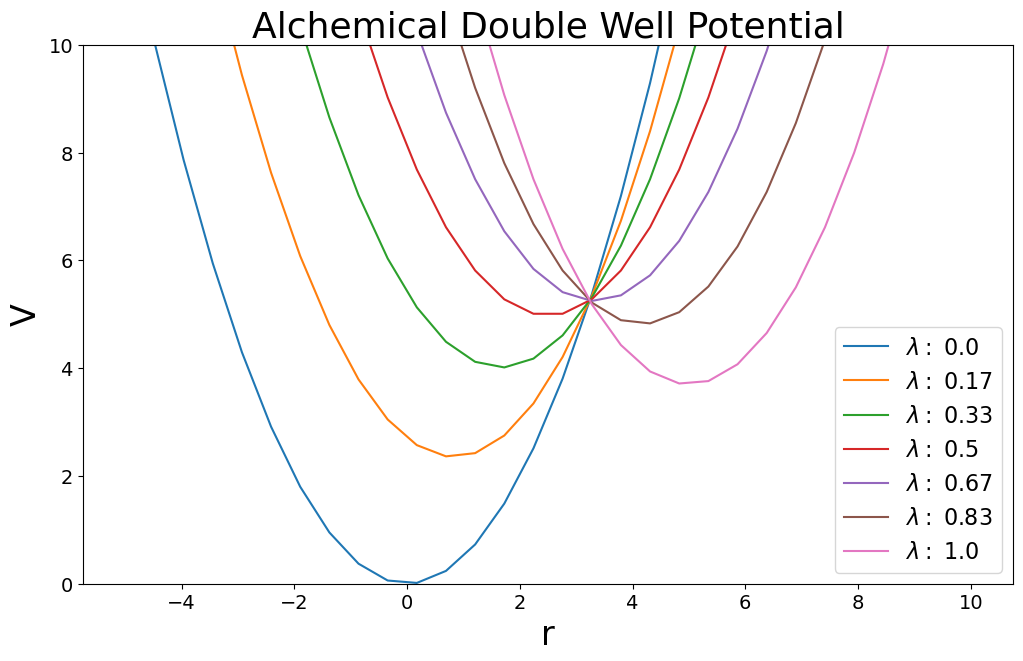

In [185]:
#Calculate dw pot via lambda space.
lambda_space = np.linspace(0,1, 7)
for lam in lambda_space:
    alchemicalState.set_lambda(lam)
    Vs = alchemicalState.ene(r)
    plt.plot(r, Vs, label=f"$\lambda:$ {round(lam,2)}")

plt.legend()
plt.ylim([0,10])
plt.ylabel("V")
plt.xlabel("r")
plt.title("Alchemical Double Well Potential")


In [186]:
# 1. Step: Calculate an Optimization and get only the minima results
lambda_space= np.linspace(0,1, 10)
minVs, minRs, minDvdlam = calculate_optimization(alchemicalState, lambda_space=lambda_space)

# Step 2: calculate thermodyn length

#Assume it's symmetric
w_symm = simpson(np.abs(minDvdlam),x=lambda_space)/2

# work of the symmetric case to cross the barrier:
forwad_indices = np.where(minDvdlam>0)[0]
rf = lambda_space[forwad_indices]
dvdlams_f = minDvdlam[forwad_indices]
w_f = simpson(dvdlams_f,x=rf)

# work of the symmetric case to cross the barrier:
reverse_indices = np.where(minDvdlam<0)[0]
rr = lambda_space[reverse_indices]
dvdlams_r = minDvdlam[reverse_indices]
w_r =  simpson(dvdlams_r,x=rr)

w_symm, w_f, w_r = list(np.round([w_symm, w_f, w_r],3))

print("Transformation Work")
print("\tsymmetric/average", w_symm)
print("\tforward A->Barrier", w_f)
print("\treverse B->Barrier", w_r)

Transformation Work
	symmetric/average 3.395
	forward A->Barrier 5.142
	reverse B->Barrier -1.544


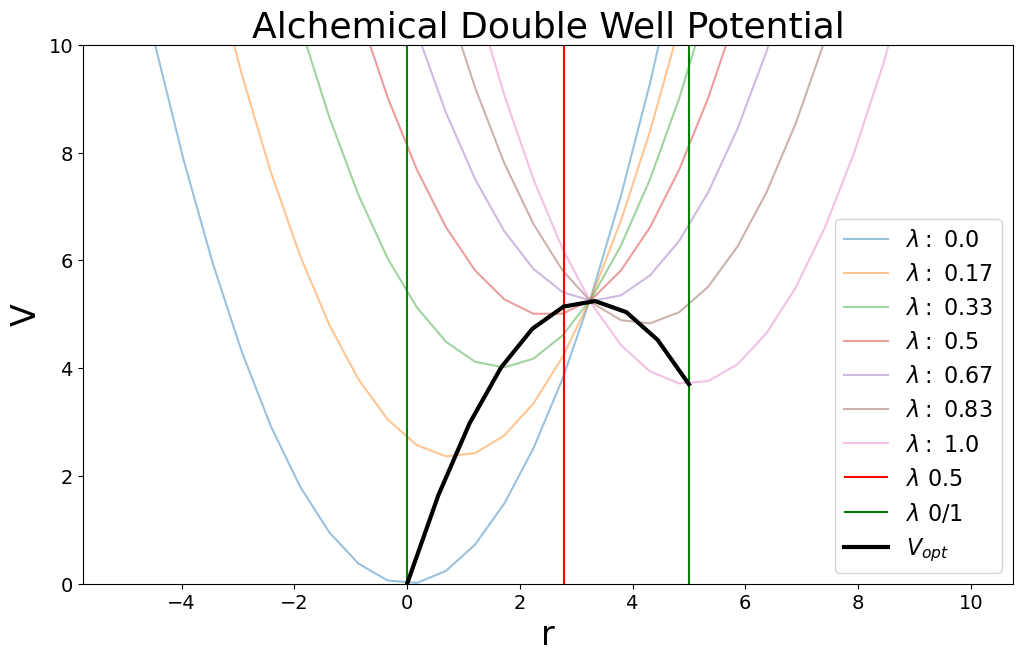

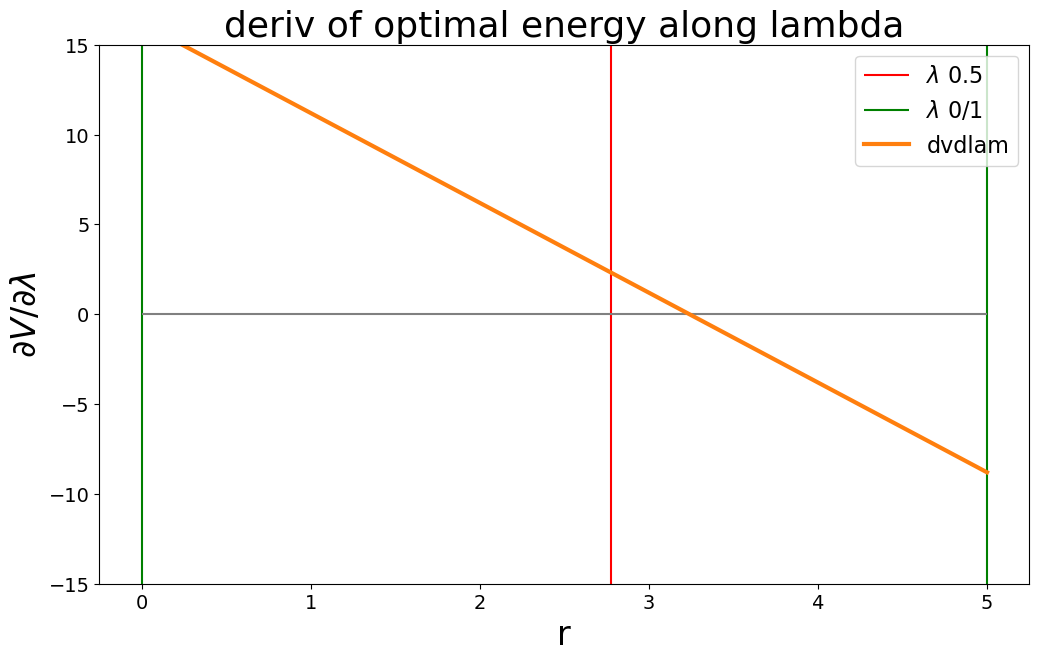

In [187]:
#Plot Calculation result:
vis_optimization(alchemicalState,minVs, minRs, minDvdlam)


# More Overlap:

Text(0.5, 1.0, 'Alchemical Double Well Potential')

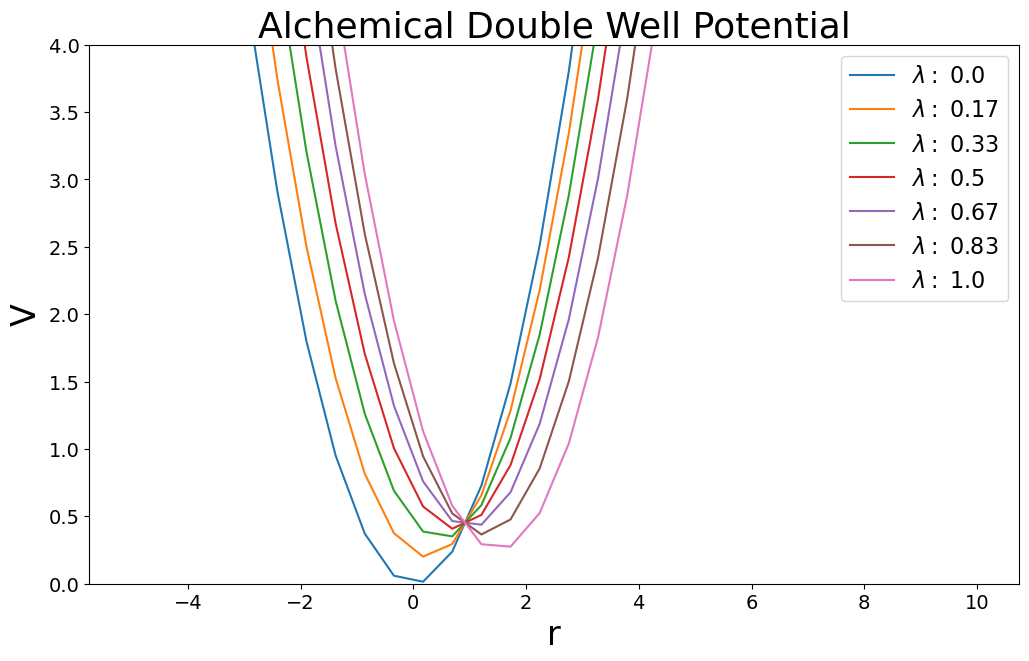

In [189]:
# Note very reduced units ahead!
#coordinate dimension (e.g. bond length)
r=np.linspace(-5,10,30)

# two different states for the dw potential (e.g. 2 diff bond types)
stateA = pot.harmonicOscillatorPotential(k=1, x_shift=0, y_shift=0)
stateB = pot.harmonicOscillatorPotential(k=1, x_shift=1.5, y_shift=0.25)

# linear coupling of potential = Alchemical Potential
alchemicalState = pot.linearCoupledPotentials(Va=stateA, Vb=stateB, 
                                                   lam=0.5)

#Calculate dw pot via lambda space.
lambda_space = np.linspace(0,1, 7)
for lam in lambda_space:
    alchemicalState.set_lambda(lam)
    Vs = alchemicalState.ene(r)
    plt.plot(r, Vs, label=f"$\lambda:$ {round(lam,2)}")

plt.legend()
plt.ylim([0,4])
plt.ylabel("V")
plt.xlabel("r")
plt.title("Alchemical Double Well Potential")


In [190]:
# 1. Step: Calculate an Optimization and get only the minima results
lambda_space= np.linspace(0,1, 10)
minVs, minRs, minDvdlam = calculate_optimization(alchemicalState, lambda_space=lambda_space)

# Step 2: calculate thermodyn length

#Assume it's symmetric
w_symm = simpson(np.abs(minDvdlam),x=lambda_space)/2

# work of the symmetric case to cross the barrier:
forwad_indices = np.where(minDvdlam>0)[0]
rf = lambda_space[forwad_indices]
dvdlams_f = minDvdlam[forwad_indices]
w_f = simpson(dvdlams_f,x=rf)

# work of the symmetric case to cross the barrier:
reverse_indices = np.where(minDvdlam<0)[0]
if(len(reverse_indices)>0):
    rr = lambda_space[reverse_indices]
    dvdlams_r = minDvdlam[reverse_indices]
    w_r =  simpson(dvdlams_r,x=rr)


w_symm, w_f, w_r = list(np.round([w_symm, w_f, w_r],3))

print("Transformation Work")
print("\tsymmetric/average", w_symm)
print("\tforward A->Barrier", w_f)
if(len(reverse_indices)>0): print("\treverse B->Barrier", w_r)

Transformation Work
	symmetric/average 0.296
	forward A->Barrier 0.417
	reverse B->Barrier -0.167


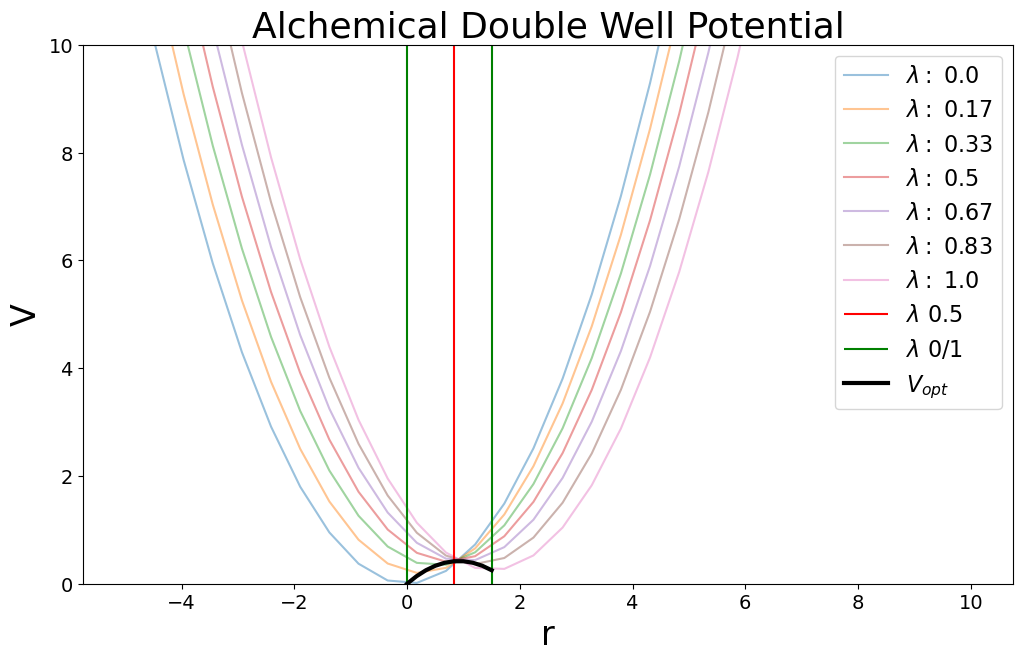

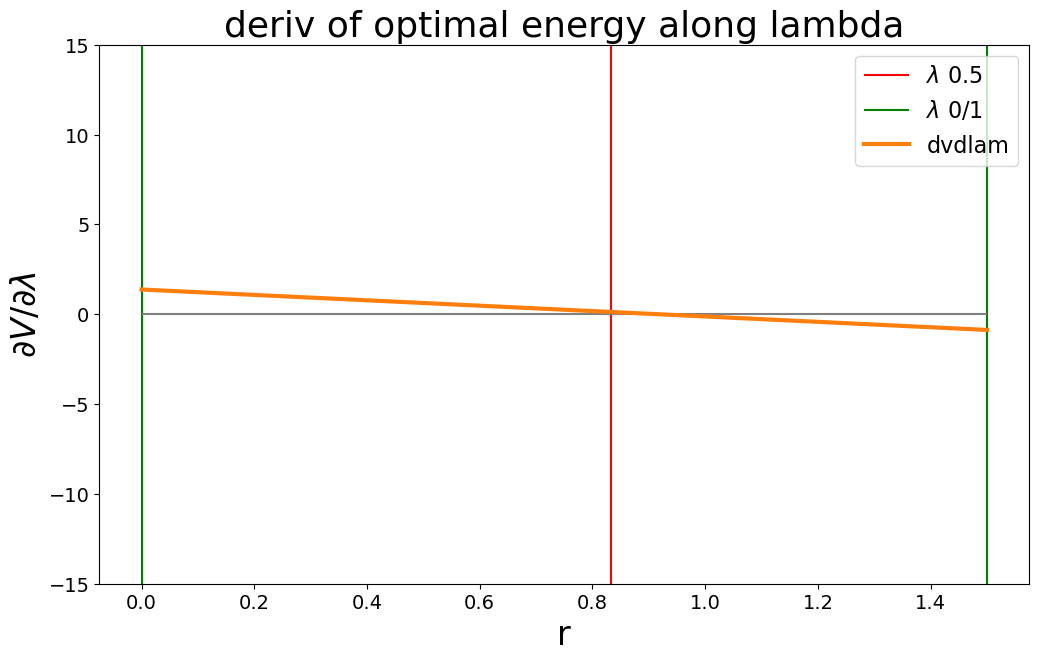

In [192]:
#Plot Calculation result:
vis_optimization(alchemicalState,minVs, minRs, minDvdlam)
